In [16]:
from IPython.core.debugger import DEBUGGERSKIP
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import tree
import graphviz
wine_data = pd.read_csv('./drive/MyDrive/winequalityN.csv')
wine_data.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [17]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [18]:
wine_data.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [19]:
data = wine_data[['alcohol', 'residual sugar', 'pH']]
target = wine_data['type']

data.fillna(data.mean(), inplace=True)

/tmp/ipython-input-3900445101.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna(data.mean(), inplace=True)


In [20]:
data

,alcohol,residual sugar,pH
0,8.8,20.7,3.00
1,9.5,1.6,3.30
2,10.1,6.9,3.26
3,9.9,8.5,3.19
4,9.9,8.5,3.19
...,...,...,...
6492,10.5,2.0,3.45
6493,11.2,2.2,3.52
6494,11.0,2.3,3.42
6495,10.2,2.0,3.57


In [21]:
train_data, test_data, train_target, test_target=train_test_split(data,target,test_size=0.2,random_state=42)
print(train_data.shape,test_data.shape)

(5197, 3) (1300, 3)


In [23]:
ss = StandardScaler()
ss.fit(train_data)
train_scaled = ss.transform(train_data)
test_scaled = ss.transform(test_data)

In [26]:
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(train_scaled, train_target)
print(clf.score(train_scaled, train_target))
print(clf.score(test_scaled, test_target))
print(clf.classes_)
print(clf.feature_importances_)

0.8487588993650182
0.8592307692307692
['red' 'white']
[0.08848347 0.901631   0.00988553]


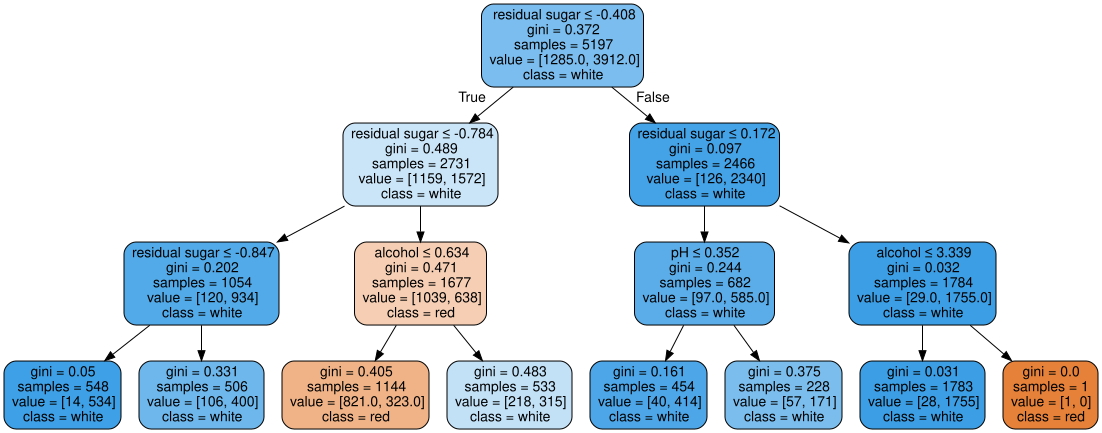

In [28]:
dot_data = tree.export_graphviz(clf,out_file=None,
                                feature_names=data.columns,
                                class_names=clf.classes_,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [29]:
new = [15, 10, 3]
clf.predict([new])

array(['red'], dtype=object)

In [30]:
import pandas as pd
data = pd.read_csv('./drive/MyDrive/Car_Purchasing_Data.csv')
data.head()

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1,57,59729.15130,5358.712177,560304.0671,55915.46248


In [35]:
X = ['Gender', 'Age', 'Annual Salary', 'Credit Card Debt', 'Net Worth']
X = data[list(X)]
y = data['Car Purchase Amount']

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=1)

from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor(max_depth=3)
reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))

0.6233804735945403


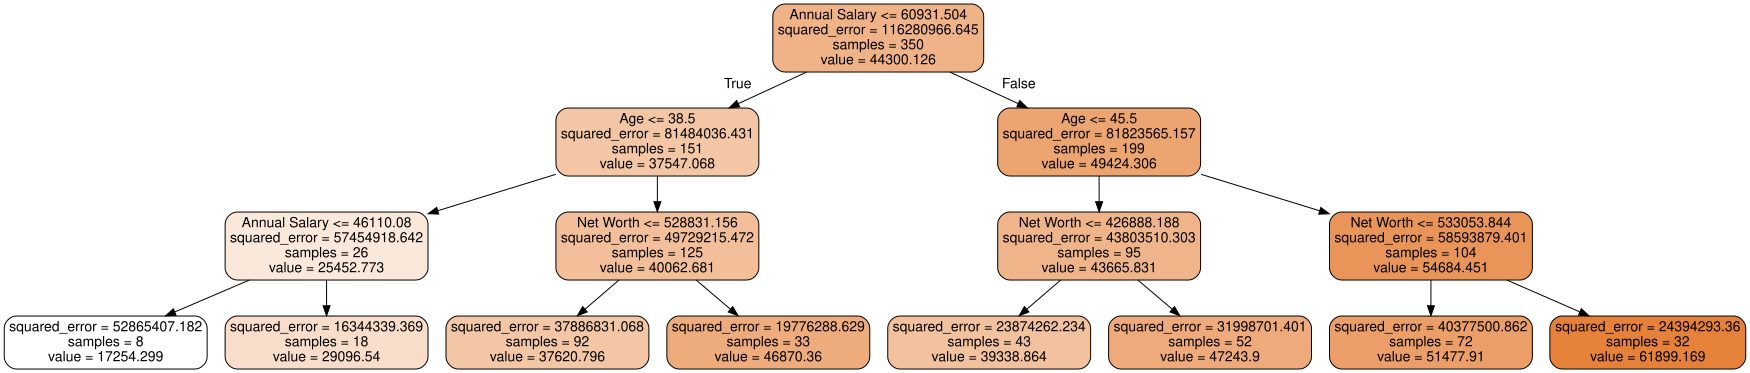

In [39]:
from sklearn import tree
import graphviz
dot_data = tree.export_graphviz(reg, out_file=None,
                                 feature_names=['Gender', 'Age', 'Annual Salary', 'Credit Card Debt', 'Net Worth'],
                                 filled=True, rounded=True)
graph = graphviz.Source(dot_data)
graph

In [41]:
new = [1, 30, 59729, 9572, 764531]
pred = reg.predict([new])
print(pred)

[29096.53984889]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [42]:
price = pred[0].astype(int) * 1390
print(price)

40443440
